In [7]:
# 1. IMPORT LIBRARIES & CONFIGURATION
import pandas as pd
import numpy as np
import pickle
import os
import re
from math import log2
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from tqdm.auto import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords', quiet=True)
plt.style.use('ggplot')

# Cau hinh thu muc
RAW_DIR = "../data/raw"
PREPROCESSED_DIR = "../data/processed"
MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)
TV2_OUT = os.path.join(PREPROCESSED_DIR, "tv2")

for directory in [MODEL_DIR, TV2_OUT]:
    os.makedirs(directory, exist_ok=True)

In [8]:
# 2. QUERY PREPROCESSING FUNCTION
stop_words = set(stopwords.words('english'))

def preprocess_query(text):
    if not isinstance(text, str): 
        return ""
    text = re.sub(r'[^a-zA-Z0-9\s\-\.\,]', ' ', str(text).lower())
    tokens = [w for w in text.split() if len(w) > 1 and w not in stop_words]
    return " ".join(tokens)

In [9]:
# 3. LOAD DATA
print("Tai Corpus TV2 da xu ly...")
df_lsa = pd.read_parquet(f"{PREPROCESSED_DIR}/data_tv2.parquet")
df_lsa['_id'] = df_lsa['_id'].astype(str)

print("Tai Queries va Qrels tu data/raw...")
df_queries = pd.read_parquet(f"{RAW_DIR}/queries.parquet")
df_qrels = pd.read_parquet(f"{RAW_DIR}/qrels.parquet")

# Chuyen doi sang Dictionary de tang toc do truy xuat
queries_dict = dict(zip(df_queries['_id'].astype(str), df_queries['text']))
qrels_dict = {}

qid_col = 'query-id' if 'query-id' in df_qrels.columns else 'query_id'
doc_col = 'corpus-id' if 'corpus-id' in df_qrels.columns else 'doc_id'

for _, row in df_qrels.iterrows():
    qid = str(row[qid_col])
    docid = str(row[doc_col])
    score = int(row['score'])
    
    if qid not in qrels_dict: 
        qrels_dict[qid] = {}
    qrels_dict[qid][docid] = score

print(f"Data Loaded - Corpus: {len(df_lsa):,} | Queries: {len(queries_dict):,}")

Tai Corpus TV2 da xu ly...
Tai Queries va Qrels tu data/raw...
Data Loaded - Corpus: 25,657 | Queries: 1,000


In [10]:
# 4. DEFINE LSA SEARCH ENGINE CLASS
class LSASearchEngine:
    def __init__(self, df, text_col='text_lsa', n_components=768):
        self.df = df
        self.doc_ids = df['_id'].tolist()
        
        print("1. Xây dựng ma trận TF-IDF...")
        self.vectorizer = TfidfVectorizer(
            max_features=150000,      # Tăng mạnh
            sublinear_tf=True,
            min_df=1,
            max_df=0.95,
            ngram_range=(1, 2)        # Bigram rất quan trọng cho SciDocs
        )
        tfidf_matrix = self.vectorizer.fit_transform(self.df[text_col].fillna(''))
        
        print(f"2. Thực hiện phân rã SVD với k={n_components}...")
        self.svd = TruncatedSVD(n_components=n_components, random_state=42)
        lsa_matrix_raw = self.svd.fit_transform(tfidf_matrix)
        
        print("3. Chuẩn hóa Vector L2...")
        self.lsa_matrix = normalize(lsa_matrix_raw, axis=1)
        
        print("Hệ thống LSA đã khởi tạo hoàn tất.")

In [11]:
# 5. INITIALIZE ENGINE AND SAVE MODEL
n_components = 768 

print(f"Khởi tạo LSA với {n_components} chiều...")
lsa_engine = LSASearchEngine(df_lsa, text_col='text_lsa', n_components=n_components)

# Lưu model
model_data = {
    'vectorizer': lsa_engine.vectorizer,
    'svd': lsa_engine.svd,
    'lsa_matrix': lsa_engine.lsa_matrix,
    'doc_ids': lsa_engine.doc_ids,
    'titles': df_lsa['title'].tolist(),
    'n_components': n_components
}

model_path = f"{MODEL_DIR}/lsa_engine_v2_{n_components}d.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model_data, f)

print(f"Đã lưu model: {model_path}")

Khởi tạo LSA với 768 chiều...
1. Xây dựng ma trận TF-IDF...
2. Thực hiện phân rã SVD với k=768...
3. Chuẩn hóa Vector L2...
Hệ thống LSA đã khởi tạo hoàn tất.
Đã lưu model: ../models/lsa_engine_v2_768d.pkl


In [12]:
# 6. DEFINE EVALUATION LOGIC
def evaluate_lsa(engine, queries, qrels, k_vals=[5, 10, 20]):
    valid_qids = [qid for qid in queries.keys() if qid in qrels]
    
    q_texts = [preprocess_query(queries[qid]) for qid in valid_qids]
    q_vecs = engine.svd.transform(engine.vectorizer.transform(q_texts))
    q_vecs = normalize(q_vecs, axis=1)
    
    sim_matrix = np.dot(q_vecs, engine.lsa_matrix.T)
    
    records = []
    for i, qid in enumerate(tqdm(valid_qids, desc="Đánh giá LSA")):
        scores = sim_matrix[i]
        relevant = qrels[qid]
        
        top_indices = np.argsort(scores)[::-1][:max(k_vals)]
        retrieved_ids = [engine.doc_ids[idx] for idx in top_indices]
        
        res = {'query_id': qid, 'method': 'LSA'}
        total_rel = sum(1 for v in relevant.values() if v > 0)
        
        for k in k_vals:
            hits = sum(1 for d in retrieved_ids[:k] if relevant.get(d, 0) > 0)
            res[f'P@{k}'] = hits / k
            res[f'R@{k}'] = hits / total_rel if total_rel > 0 else 0
            
            dcg = sum([relevant.get(d, 0) / log2(rank + 2) for rank, d in enumerate(retrieved_ids[:k])])
            idcg = sum([1 / log2(rank + 2) for rank in range(min(total_rel, k))])
            res[f'NDCG@{k}'] = dcg / idcg if idcg > 0 else 0
            
        # MRR
        mrr = 0
        for rank, d in enumerate(retrieved_ids):
            if relevant.get(d, 0) > 0:
                mrr = 1 / (rank + 1)
                break
        res['MRR'] = mrr
        
        # Giữ AP để tính MAP (rất quan trọng)
        ap, hits_total = 0.0, 0
        for rank, d in enumerate(retrieved_ids):
            if relevant.get(d, 0) > 0:
                hits_total += 1
                ap += hits_total / (rank + 1)
        res['AP'] = ap / total_rel if total_rel > 0 else 0.0
        
        records.append(res)
        
    return pd.DataFrame(records)

In [13]:
# 7. EXECUTE EVALUATION AND SAVE RESULTS
df_results = evaluate_lsa(lsa_engine, queries_dict, qrels_dict)

# Tính trung bình
summary = df_results.drop(columns=['query_id', 'method']).mean().round(4)

print("\n" + "="*75)
print("                 KẾT QUẢ ĐÁNH GIÁ - LSA".center(75))
print("="*75)

# Bảng chi tiết (có AP)
print(f"{'method':<8} {'k':<3} {'P@k':<8} {'R@k':<8} {'NDCG@k':<9} {'MRR':<8} {'AP':<8}")
print("-" * 75)

for k in [5, 10, 20]:
    p    = summary[f'P@{k}']
    r    = summary[f'R@{k}']
    ndcg = summary[f'NDCG@{k}']
    mrr  = summary['MRR']
    ap   = summary['AP']
    
    print(f"{'LSA':<8} {k:<3} {p:<8} {r:<8} {ndcg:<9} {mrr:<8} {ap:<8}")

# Hiển thị MAP
print("\n" + "-"*75)
print("MAP (Mean Average Precision):")
print(f"{'LSA':<8} {summary['AP']:.4f}")
print("-"*75)

print(f"Đã lưu đầy đủ kết quả tại: {TV2_OUT}")

Đánh giá LSA:   0%|          | 0/1000 [00:00<?, ?it/s]


                                   KẾT QUẢ ĐÁNH GIÁ - LSA                  
method   k   P@k      R@k      NDCG@k    MRR      AP      
---------------------------------------------------------------------------
LSA      5   0.0862   0.0872   0.0974    0.221    0.0778  
LSA      10  0.0672   0.1361   0.1239    0.221    0.0778  
LSA      20  0.047    0.1907   0.1472    0.221    0.0778  

---------------------------------------------------------------------------
MAP (Mean Average Precision):
LSA      0.0778
---------------------------------------------------------------------------
Đã lưu đầy đủ kết quả tại: ../data/processed/tv2


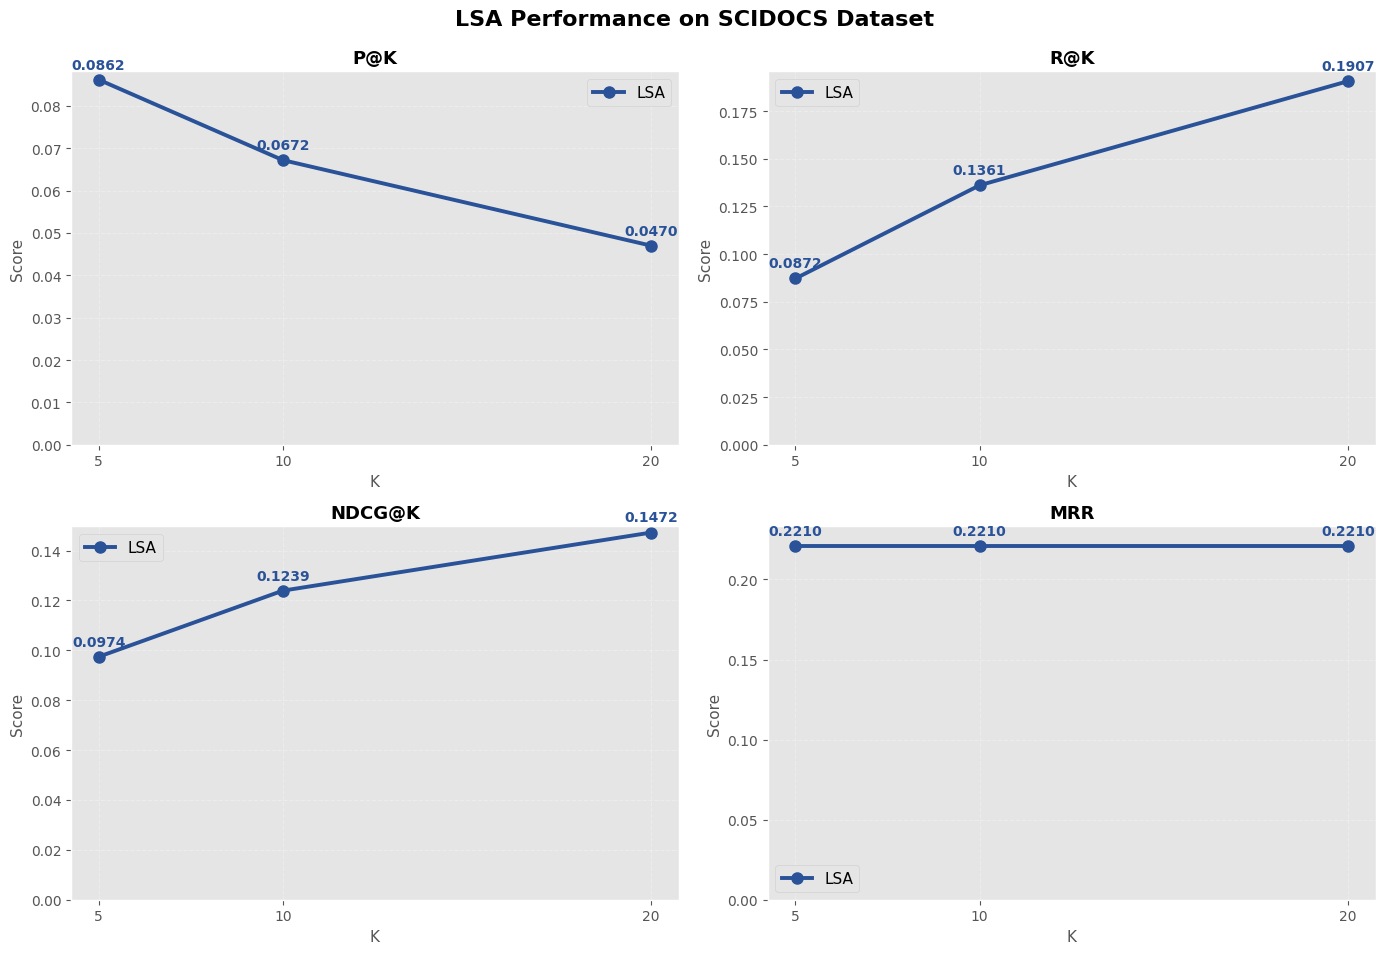

Đã lưu biểu đồ tại: ../data/processed/tv2/lsa_performance_chart.png


In [14]:
# 8. VISUALIZATION - Phong cách giống TF-IDF
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LSA Performance on SCIDOCS Dataset', 
             fontsize=16, fontweight='bold', y=0.95)

metrics = ['P@K', 'R@K', 'NDCG@K', 'MRR']
k_vals = [5, 10, 20]
colors = '#2a5298'  # Màu xanh đậm giống TF-IDF

for ax, metric in zip(axes.flatten(), metrics):
    vals = []
    for k in k_vals:
        try:
            col_name = f'{metric.split("@")[0]}@{k}' if '@' in metric else metric
            vals.append(summary[col_name])
        except:
            vals.append(0)
    
    # Vẽ đường
    ax.plot(k_vals, vals, label='LSA', color=colors, 
            linewidth=2.8, marker='o', markersize=8, linestyle='-')
    
    # Hiển thị giá trị trên điểm
    for k, v in zip(k_vals, vals):
        ax.annotate(f'{v:.4f}', xy=(k, v), xytext=(0, 8),
                    textcoords='offset points', ha='center',
                    fontsize=10, fontweight='bold', color=colors)
    
    ax.set_title(f'{metric}', fontweight='bold', fontsize=13)
    ax.set_xlabel('K', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_xticks(k_vals)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.96])
chart_path = f"{TV2_OUT}/lsa_performance_chart.png"
plt.savefig(chart_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Đã lưu biểu đồ tại: {chart_path}")

In [17]:
import os
import pickle

# Khai báo thư mục chuẩn cho Thành viên 2
MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Đóng gói toàn bộ mô hình và dữ liệu hiển thị
model_data = {
    'vectorizer': lsa_engine.vectorizer,
    'svd':        lsa_engine.svd,
    'lsa_matrix': lsa_engine.lsa_matrix,
    'doc_ids':    lsa_engine.doc_ids,
    'titles':     df_lsa['title'].tolist(),
    'abstracts':  df_lsa['abstract'].tolist(), # Thêm abstract để bắn lên giao diện Web
}

# Lưu file an toàn bằng 'with open'
save_path = f'{MODEL_DIR}/lsa_model.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(model_data, f)

size = os.path.getsize(save_path) / 1024 / 1024
print(f"📦 Dung lượng file: {size:.2f} MB")

📦 Dung lượng file: 1095.97 MB
